# Coal-CCS ATB 2024 — Envelope multipliers (moderate × multiplier)

This notebook:
1. Loads **advanced / moderate / conservative** CSVs from raw GitHub URLs
2. (Optional) filters to a single technology row-id `i`
3. Fits least-squares multipliers mapping `moderate → advanced` and `moderate → conservative` over years ≥ `START_YEAR`
4. Builds an envelope: `moderate × [low_mult, high_mult]`
5. Plots results and saves a multipliers table.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ---------------------------
# CONFIG (edit these)
# ---------------------------

FILE_URLS = {
    "advanced": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/coal-ccs_ATB_2024_advanced.csv",
    "moderate": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/coal-ccs_ATB_2024_moderate.csv",
    "conservative": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/coal-ccs_ATB_2024_conservative.csv",
}

# If these CSVs include multiple technologies in column `i`,
# set TECH_FILTER to a specific value like "coal-CCS_mod".
# Otherwise leave as None.
TECH_FILTER = "coal-CCS_mod"  # or None

METRICS = ["capcost", "fom", "vom", "heatrate"]

START_YEAR = 2025
SAVE_CSV = True
OUT_CSV = "coal_ccs_envelope_multipliers.csv"

In [3]:
def load_from_urls(urls: dict) -> pd.DataFrame:
    dfs = []
    for scen, url in urls.items():
        df = pd.read_csv(url)
        df["scenario"] = scen
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)

    # normalize types
    out["t"] = pd.to_numeric(out["t"], errors="coerce")
    out = out.dropna(subset=["t"]).copy()
    out["t"] = out["t"].astype(int)

    # Optional filter on technology id
    if "i" in out.columns and TECH_FILTER is not None:
        out = out[out["i"] == TECH_FILTER].copy()

    return out.sort_values(["scenario", "t"]).reset_index(drop=True)

df = load_from_urls(FILE_URLS)
df.head()

,i,t,capcost,fom,vom,heatrate,scenario
0,coal-CCS_mod,2010,5125.032,131.868,15.8652,10.938,advanced
1,coal-CCS_mod,2011,5125.032,131.868,15.8652,10.938,advanced
2,coal-CCS_mod,2012,5125.032,131.868,15.8652,10.938,advanced
3,coal-CCS_mod,2013,5125.032,131.868,15.8652,10.938,advanced
4,coal-CCS_mod,2014,5125.032,131.868,15.8652,10.938,advanced


In [4]:
def fit_multiplier_ls(moderate: pd.Series, target: pd.Series) -> float:
    """Least-squares scalar m minimizing ||m*moderate - target||^2 over aligned years."""
    m = moderate.values.astype(float)
    y = target.values.astype(float)
    denom = float(np.dot(m, m))
    if denom == 0:
        return np.nan
    return float(np.dot(m, y) / denom)

def envelope_multipliers(df: pd.DataFrame, metric: str, start_year: int = 2025) -> dict:
    piv = (df[["t", "scenario", metric]]
           .dropna(subset=["t", metric])
           .pivot(index="t", columns="scenario", values=metric)
           .sort_index())

    for s in ["moderate", "advanced", "conservative"]:
        if s not in piv.columns:
            raise ValueError(f"Missing scenario '{s}' for metric '{metric}'. Found: {list(piv.columns)}")

    window = piv.loc[piv.index >= start_year].dropna(subset=["moderate", "advanced", "conservative"], how="any")
    if len(window) < 2:
        raise ValueError(f"Not enough overlapping years >= {start_year} for metric '{metric}'.")

    M = window["moderate"]
    mA = fit_multiplier_ls(M, window["advanced"])
    mC = fit_multiplier_ls(M, window["conservative"])

    low_mult = float(np.nanmin([mA, mC]))
    high_mult = float(np.nanmax([mA, mC]))
    low_ref = "advanced" if mA <= mC else "conservative"
    high_ref = "advanced" if mA >= mC else "conservative"

    return {
        "metric": metric,
        "mA": mA,
        "mC": mC,
        "low_mult": low_mult,
        "high_mult": high_mult,
        "low_ref": low_ref,
        "high_ref": high_ref,
        "n_years_fit": int(len(window)),
        "fit_year_min": int(window.index.min()),
        "fit_year_max": int(window.index.max()),
    }

def plot_with_envelope(df: pd.DataFrame, metric: str, start_year: int = 2025):
    info = envelope_multipliers(df, metric, start_year=start_year)

    piv = (df[["t", "scenario", metric]]
           .dropna(subset=["t", metric])
           .pivot(index="t", columns="scenario", values=metric)
           .sort_index())

    years = piv.index
    M_all = piv["moderate"]
    env_low = M_all * info["low_mult"]
    env_high = M_all * info["high_mult"]

    # mask so envelope starts at START_YEAR
    mask = years >= start_year
    yrs_env = years[mask]

    plt.figure(figsize=(10, 5))

    plt.figure(figsize=(10, 5))
        # envelope shading only from start_year
    plt.fill_between(
        yrs_env,
        env_low.loc[yrs_env].values,
        env_high.loc[yrs_env].values,
        alpha=0.12,
        label=f"Envelope (≥ {start_year})"
    )

    plt.plot(years, piv["moderate"].values, linewidth=2.2, label="Moderate")
    plt.plot(years, piv["advanced"].values, linewidth=2.2, label="Advanced")
    plt.plot(years, piv["conservative"].values, linewidth=2.2, label="Conservative")
    plt.plot(years, env_low.values, "--", label=f"Low: moderate × {info['low_mult']:.4g} ({info['low_ref']} fit)")
    plt.plot(years, env_high.values, "--", label=f"High: moderate × {info['high_mult']:.4g} ({info['high_ref']} fit)")
    plt.axvline(start_year, linewidth=1)

    title_i = ""
    if "i" in df.columns and TECH_FILTER is not None:
        title_i = f" ({TECH_FILTER})"

    plt.title(f"{metric}{title_i}: LS envelope using years ≥ {start_year}")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return info

<Figure size 1000x500 with 0 Axes>

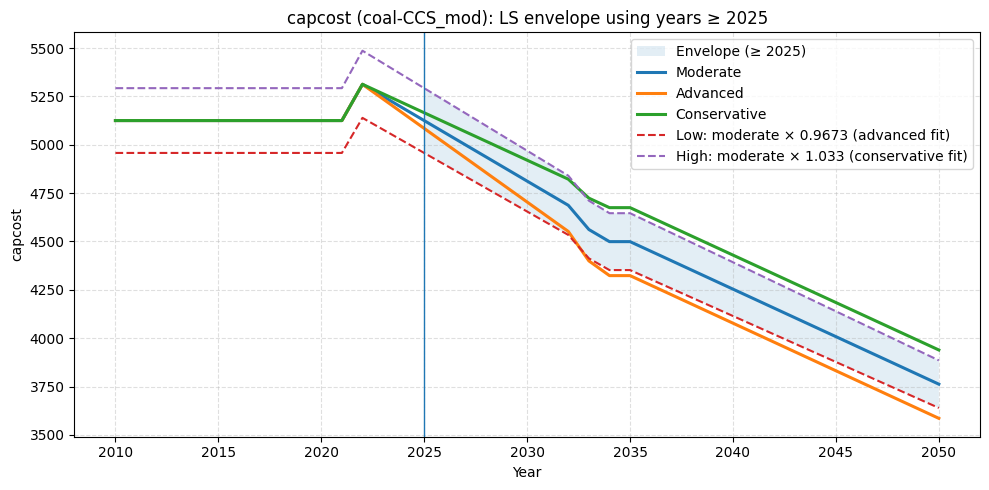

<Figure size 1000x500 with 0 Axes>

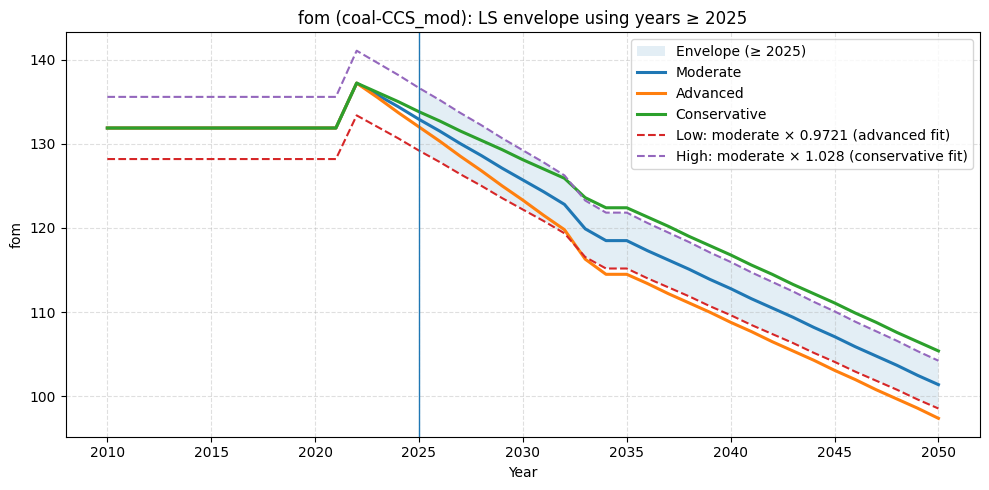

<Figure size 1000x500 with 0 Axes>

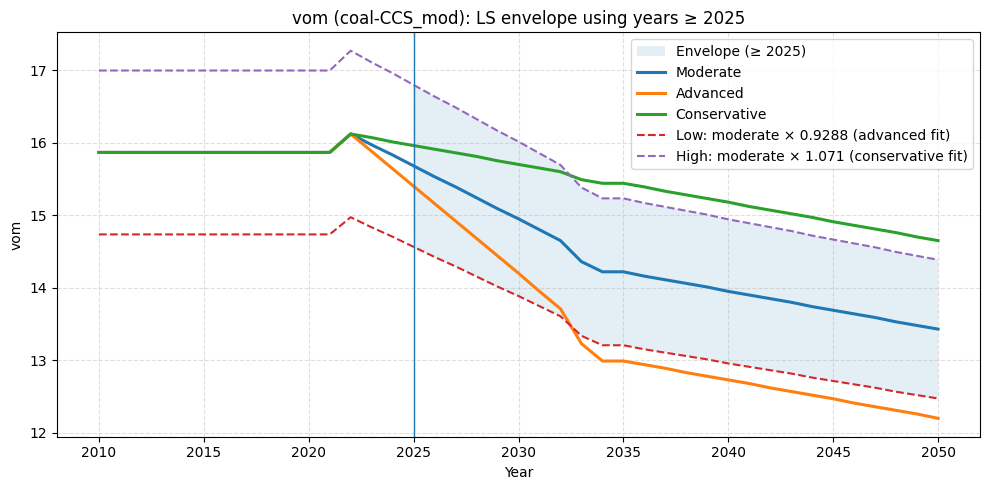

<Figure size 1000x500 with 0 Axes>

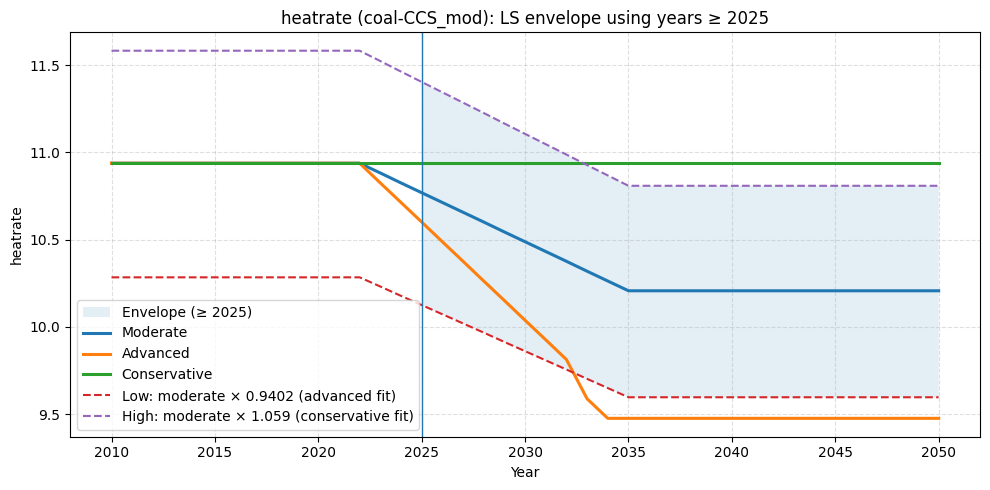

,metric,mA,mC,low_mult,high_mult,low_ref,high_ref,n_years_fit,fit_year_min,fit_year_max
0,capcost,0.967325,1.032678,0.967325,1.032678,advanced,conservative,26,2025,2050
1,fom,0.972064,1.028033,0.972064,1.028033,advanced,conservative,26,2025,2050
2,vom,0.928794,1.071189,0.928794,1.071189,advanced,conservative,26,2025,2050
3,heatrate,0.940218,1.058951,0.940218,1.058951,advanced,conservative,26,2025,2050


In [5]:
# Run + plot
results = []
for m in METRICS:
    results.append(plot_with_envelope(df, m, start_year=START_YEAR))

res = pd.DataFrame(results)
res

In [6]:
if SAVE_CSV:
    res.to_csv(OUT_CSV, index=False)
    print("Saved:", OUT_CSV)

Saved: coal_ccs_envelope_multipliers.csv


In [7]:
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
METRICS = ["capcost", "fom", "vom", "heatrate"]
START_YEAR = 2025
TECH_FILTER = "coal-CCS_mod"   # must match the `i` values in the file

n_samples = 2
seed = 123
rng = np.random.default_rng(seed)

out_dir = Path("coal_ccs_sampling_outputs")
out_dir.mkdir(exist_ok=True)

# ============================================================
# 1) Get per-metric bounds (low/high) from your envelope results
#    - If you already have a results table, reuse it.
#    - Otherwise compute it using your envelope_multipliers() function.
# ============================================================
bounds_df = None

# Common names people use in the notebook for the envelope result table:
for cand in ["res_df", "results_df", "df_env", "env_df", "res"]:
    if cand in globals() and isinstance(globals()[cand], pd.DataFrame):
        dfc = globals()[cand].copy()
        if ("metric" in dfc.columns) and ("low_mult" in dfc.columns) and ("high_mult" in dfc.columns):
            bounds_df = dfc[["metric", "low_mult", "high_mult"]].copy()
            break

# If not found, compute bounds now (requires your envelope_multipliers() and loaded df_all)
if bounds_df is None:
    if "envelope_multipliers" not in globals():
        raise NameError("Could not find envelope_multipliers(). Make sure you ran the earlier envelope cells.")
    if "df_all" not in globals():
        # If your notebook uses a different name for the loaded scenario dataframe, adjust here.
        raise NameError("Could not find df_all (the combined scenario dataframe). Make sure you ran the data-load cell.")

    tmp = []
    for m in METRICS:
        info = envelope_multipliers(df_all, metric=m, start_year=START_YEAR)
        tmp.append({"metric": m, "low_mult": info["low_mult"], "high_mult": info["high_mult"]})
    bounds_df = pd.DataFrame(tmp)

bounds_df = bounds_df.set_index("metric").loc[METRICS].copy()

print("\nPer-metric envelope bounds:")
display(bounds_df)

# ============================================================
# 2) Sample multipliers per metric and print in list format
# ============================================================
samples_by_metric = {}

for m in METRICS:
    lo = float(min(bounds_df.loc[m, "low_mult"], bounds_df.loc[m, "high_mult"]))
    hi = float(max(bounds_df.loc[m, "low_mult"], bounds_df.loc[m, "high_mult"]))
    samples_by_metric[m] = rng.uniform(lo, hi, size=n_samples).tolist()

    print(f"\n{m}_scalars = [")
    for s in samples_by_metric[m]:
        print(f"  {s:.8f},")
    print("]")

# Save the multipliers used for each sample (very useful later)
mult_table = pd.DataFrame({"sample_id": np.arange(1, n_samples + 1)})
for m in METRICS:
    mult_table[m + "_mult"] = samples_by_metric[m]
mult_table["start_year"] = START_YEAR
mult_table["tech"] = TECH_FILTER
mult_table["seed"] = seed
mult_table.to_csv(out_dir / "coal_ccs_metric_multiplier_samples.csv", index=False)

# ============================================================
# 3) Load the MODERATE dataset as the base series (this is what you will modify)
# ============================================================
if "FILE_URLS" not in globals():
    raise NameError("Expected FILE_URLS dict with keys like 'moderate', 'advanced', 'conservative'.")

df_mod = pd.read_csv(FILE_URLS["moderate"])
df_mod["t"] = df_mod["t"].astype(int)

# Filter to the technology row(s) you care about
if "i" in df_mod.columns:
    df_mod = df_mod[df_mod["i"] == TECH_FILTER].copy()
else:
    raise ValueError("Expected column 'i' in the ATB plant_characteristics file.")

# Enforce exact output columns (GitHub style)
needed_cols = ["i", "t"] + METRICS
missing = [c for c in needed_cols if c not in df_mod.columns]
if missing:
    raise ValueError(f"Missing required columns in moderate file: {missing}")

df_mod = df_mod[needed_cols].copy()
df_mod = df_mod.sort_values(["i", "t"]).reset_index(drop=True)

# ============================================================
# 4) Generate sampled CSVs: apply each metric multiplier to years >= START_YEAR
# ============================================================
def make_sample_file(sample_id: int) -> Path:
    df_out = df_mod.copy()

    mask = df_out["t"] >= START_YEAR
    for m in METRICS:
        df_out.loc[mask, m] = df_out.loc[mask, m].astype(float) * float(samples_by_metric[m][sample_id - 1])

    fpath = out_dir / f"coal_ccs_ATB_2024_sample_{sample_id:03d}.csv"
    df_out.to_csv(fpath, index=False)
    return fpath

files = [make_sample_file(i) for i in range(1, n_samples + 1)]

print(f"\nGenerated {len(files)} files in: {out_dir.resolve()}")
print("Example output file:", files[0])



Per-metric envelope bounds:


,low_mult,high_mult
metric,,
capcost,0.967325,1.032678
fom,0.972064,1.028033
vom,0.928794,1.071189
heatrate,0.940218,1.058951



capcost_scalars = [
  1.01191906,
  0.97084272,
]

fom_scalars = [
  0.98439693,
  0.98238271,
]

vom_scalars = [
  0.95384234,
  1.04443216,
]

heatrate_scalars = [
  1.04984980,
  0.97305625,
]

Generated 2 files in: /content/coal_ccs_sampling_outputs
Example output file: coal_ccs_sampling_outputs/coal_ccs_ATB_2024_sample_001.csv


In [8]:
from IPython.display import Markdown, display
import pandas as pd

# Example (you likely already do something like this):
# results = []
# for m in ["capcost","fom","vom","heatrate"]:
#     results.append(plot_with_envelope(df_tech, m, start_year=2025))

results_df = pd.DataFrame(results)

metric_units = {
    "capcost": r"\$/MW",
    "fom": r"\$/MW-yr",
    "vom": r"\$/MWh",
    "heatrate": r"MMBtu/MWh",
}

latex_rows = []
for _, row in results_df.iterrows():
    metric = row["metric"]
    low_mult = row["low_mult"]
    high_mult = row["high_mult"]

    parameter = rf"Coal-CCS -- {metric}"
    unit = metric_units.get(metric, "unitless")

    latex_rows.append(
        rf"{parameter} & {high_mult:.4f} & {low_mult:.4f} & {unit} (multiplier) \\"
    )

full_latex_table = rf"""
\begin{{table}}[h!]
\centering
\caption{{Sampled Multiplier Bounds and Parameter Units for Coal-CCS (ATB 2024)}}
\label{{tab:coal_ccs_metric_bounds_units}}
\begin{{tabular}}{{l c c c}}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
{chr(10).join(latex_rows)}
\bottomrule
\end{{tabular}}
\end{{table}}
"""

display(Markdown(f"```latex\n{full_latex_table}\n```"))


```latex

\begin{table}[h!]
\centering
\caption{Sampled Multiplier Bounds and Parameter Units for Coal-CCS (ATB 2024)}
\label{tab:coal_ccs_metric_bounds_units}
\begin{tabular}{l c c c}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
Coal-CCS -- capcost & 1.0327 & 0.9673 & \$/MW (multiplier) \\
Coal-CCS -- fom & 1.0280 & 0.9721 & \$/MW-yr (multiplier) \\
Coal-CCS -- vom & 1.0712 & 0.9288 & \$/MWh (multiplier) \\
Coal-CCS -- heatrate & 1.0590 & 0.9402 & MMBtu/MWh (multiplier) \\
\bottomrule
\end{tabular}
\end{table}

```

In [9]:
import numpy as np
import pandas as pd
from pathlib import Path
import shutil

# ============================================================
# USER INPUTS
# ============================================================
MORRIS_DESIGN_URL = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_design_r5_p6.csv"
FACTOR_MAP_URL    = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_factor_map.csv"

# NREL base file (moderate) — coal-CCS
NREL_MODERATE_URL = "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/coal-ccs_ATB_2024_moderate.csv"

START_YEAR = 2025

# If None, code will auto-pick the only 'i' value if there's exactly one.
TECH_FILTER = "coal-CCS_mod"

METRICS = ["capcost", "fom", "vom", "heatrate"]

OUT_DIR = Path("coal_ccs_ATB_2024_morris_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1) Load Morris design + factor map
# ============================================================
design = pd.read_csv(MORRIS_DESIGN_URL)
factor_map = pd.read_csv(FACTOR_MAP_URL)

factor_map.columns = [c.strip().lower() for c in factor_map.columns]
if "parameter" not in factor_map.columns or "factor" not in factor_map.columns:
    raise ValueError(f"factor_map must have columns ['parameter','factor']. Found: {list(factor_map.columns)}")

# ============================================================
# 2) Load NREL moderate base (preserve exact column order)
# ============================================================
base_all = pd.read_csv(NREL_MODERATE_URL)

required = ["i", "t"] + METRICS
missing = [c for c in required if c not in base_all.columns]
if missing:
    raise ValueError(f"NREL moderate file missing required columns: {missing}\nColumns found: {list(base_all.columns)}")

techs = sorted(base_all["i"].astype(str).unique().tolist())

# Auto-pick if TECH_FILTER is wrong but only one tech exists
if TECH_FILTER not in techs:
    if len(techs) == 1:
        print(f"TECH_FILTER '{TECH_FILTER}' not found. Auto-using the only tech in file: '{techs[0]}'")
        TECH_FILTER = techs[0]
    else:
        print("TECH_FILTER not found. Available values in base file 'i' column include:")
        print(techs)
        raise ValueError(f"Set TECH_FILTER to one of the exact values above. You provided: {TECH_FILTER}")

base = base_all.loc[base_all["i"].astype(str) == TECH_FILTER].copy()
base["t"] = pd.to_numeric(base["t"], errors="coerce").astype(int)

# Preserve exact output column order from the NREL file
col_order = list(base_all.columns)

# ============================================================
# 3) Resolve Morris factor columns for Coal-CCS metrics
#     We match parameter text like: "Coal-CCS -- capcost"
# ============================================================
def resolve_factor_col(tech_label: str, metric: str) -> str:
    mask = (
        factor_map["parameter"].astype(str).str.lower().str.contains(str(tech_label).lower())
        & factor_map["parameter"].astype(str).str.lower().str.contains(str(metric).lower())
    )
    hits = factor_map.loc[mask, "factor"]
    if hits.empty:
        raise ValueError(
            f"Could not find factor_map row for TECH='{tech_label}', metric='{metric}'.\n"
            f"Expected something like: '{tech_label} -- {metric}' in factor_map['parameter']."
        )
    return str(hits.iloc[0])

design_cols = {m: resolve_factor_col("Coal-CCS", m) for m in METRICS}

print("Resolved Morris design columns for Coal-CCS:")
for m, c in design_cols.items():
    print(f"  {m:10s} -> {c}")

missing_cols = [c for c in design_cols.values() if c not in design.columns]
if missing_cols:
    raise ValueError(f"These factor columns are missing from morris_design CSV: {missing_cols}")

# ============================================================
# 4) Generate one CSV per Morris run (apply multipliers for years >= START_YEAR)
# ============================================================
written_files = []
for run_idx in range(len(design)):
    df_out = base.copy()
    mask_year = df_out["t"] >= int(START_YEAR)

    for metric in METRICS:
        mult = float(design.loc[run_idx, design_cols[metric]])
        df_out.loc[mask_year, metric] = df_out.loc[mask_year, metric].astype(float) * mult

    # Keep EXACT original column order/headers like NREL file
    df_out = df_out[col_order]

    out_path = OUT_DIR / f"coal-ccs_ATB_2024_morris_{run_idx:03d}.csv"
    df_out.to_csv(out_path, index=False)
    written_files.append(out_path)

print(f"\nDone. Wrote {len(written_files)} CSV files to: {OUT_DIR.resolve()}")

# ============================================================
# 5) Zip for download
# ============================================================
zip_name = "coal_ccs_ATB_2024_morris_outputs"
zip_path = shutil.make_archive(zip_name, "zip", OUT_DIR)
print("Created zip:", zip_path)


Resolved Morris design columns for Coal-CCS:
  capcost    -> coal_ccs_capcost
  fom        -> coal_ccs_fom
  vom        -> coal_ccs_vom
  heatrate   -> coal_ccs_heatrate

Done. Wrote 200 CSV files to: /content/coal_ccs_ATB_2024_morris_outputs
Created zip: /content/coal_ccs_ATB_2024_morris_outputs.zip
